# Apple Stock Price Prediction

## Project Category
Time Series Forecasting

---

## Objective

The objective of this project is to analyze and predict Apple stock prices using time series analysis and machine learning techniques.

This project aims to:
- analyze historical stock market data,
- visualize stock price trends,
- apply forecasting techniques,
- identify moving averages,
- predict future stock prices.

---

## Dataset Information

The dataset contains historical Apple stock market data such as:

- Date
- Open Price
- High Price
- Low Price
- Close Price
- Volume

The project uses time series analysis techniques to forecast future stock prices.

---

## Algorithms and Techniques Used

- Time Series Analysis
- Moving Average
- Data Visualization
- Forecasting Techniques
- Regression Models

---

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

---

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Time Series Visualization
4. Trend Analysis
5. Moving Average Analysis
6. Forecasting Model
7. Prediction Visualization
8. Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving AAPL.csv to AAPL.csv


In [2]:
import pandas as pd

df = pd.read_csv("AAPL.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (10468, 7)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Rows:
0


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
df.set_index("Date",inplace=True)

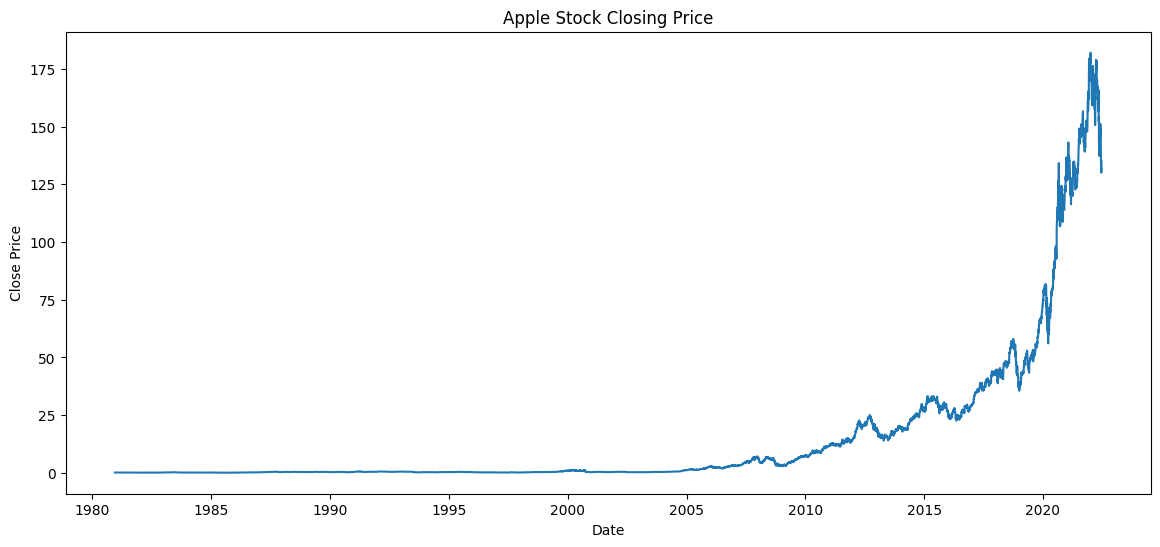

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.plot(df["Close"])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

In [7]:
### Moving Average Analysis
df["MA30"] = (df["Close"].rolling(window=30).mean())

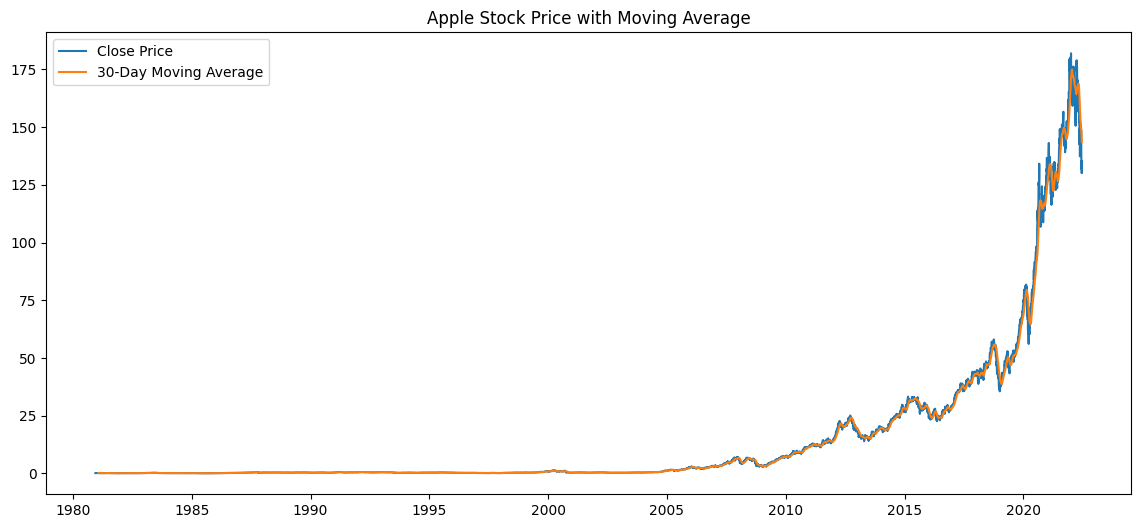

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df["Close"],
    label="Close Price")

plt.plot(df["MA30"],
    label="30-Day Moving Average")

plt.title("Apple Stock Price with Moving Average")

plt.legend()

plt.show()

In [9]:
### Forecasting Model

df["Target"] = (df["Close"].shift(-1))

In [10]:
df.dropna(inplace=True)

In [11]:
X = df[["Close"]]

y = df["Target"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False)

In [13]:
### Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error)

import numpy as np

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

MAE: 0.8677551785920691
MSE: 2.3696389804210924
RMSE: 1.539363173660164


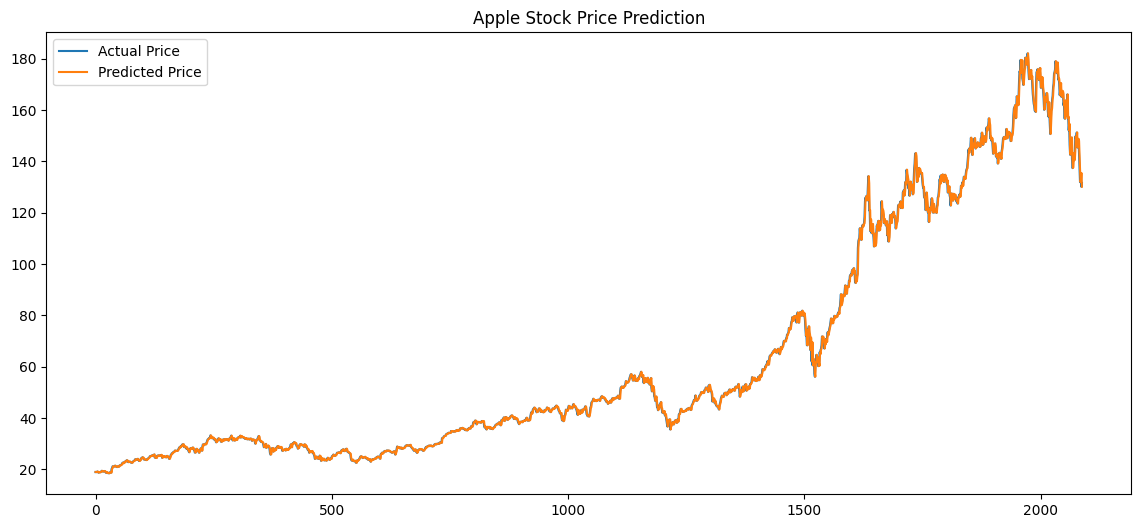

In [16]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values,label="Actual Price")

plt.plot(y_pred,label="Predicted Price")

plt.title("Apple Stock Price Prediction")

plt.legend()

plt.show()

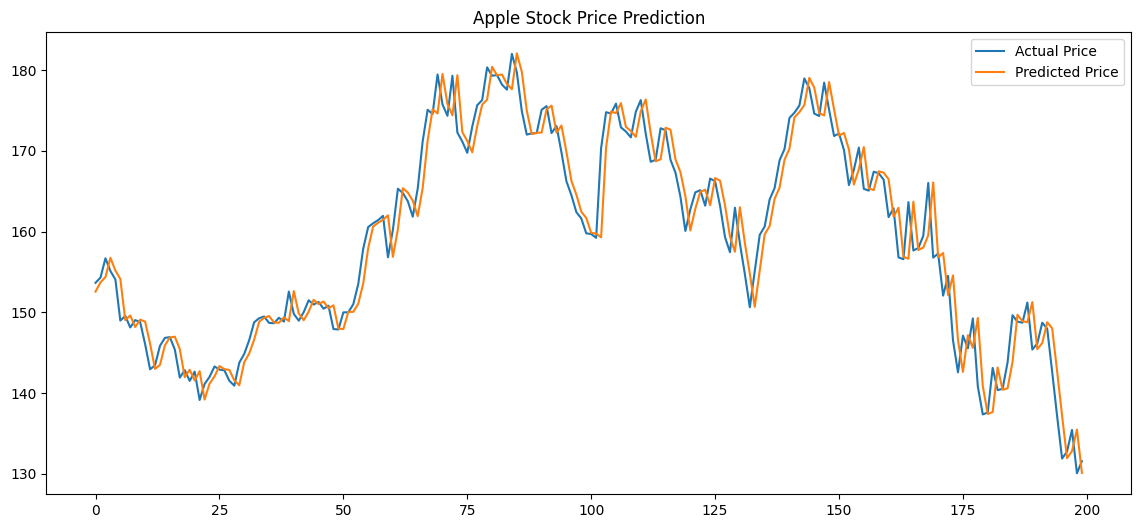

In [17]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[-200:],
    label="Actual Price")

plt.plot(y_pred[-200:],
    label="Predicted Price")

plt.title("Apple Stock Price Prediction")

plt.legend()

plt.show()

## Model Evaluation

The forecasting model achieved strong prediction performance on Apple stock prices.

### Evaluation Metrics

- MAE: 0.86
- MSE: 2.36
- RMSE: 1.53

The low MAE and RMSE values indicate that the model predicted stock prices with relatively small error.

Considering the volatility of financial markets, the forecasting performance can be considered successful for short-term stock price prediction.

The model effectively captured the overall trend and short-term fluctuations of Apple stock prices.